# Torre de Hanoi - Representabilidad y Resolución

Este notebook modela la **Torre de Hanoi** priorizando la representabilidad del estado:

1. Cada torre se representa como una **pila (stack)** usando listas de Python.
2. El estado global se modela como un diccionario con 3 torres: `A`, `B`, `C`.
3. Las reglas del sistema se respetan en cada transición:
   - Solo se mueve el disco superior de una torre.
   - No se puede colocar un disco grande sobre uno pequeño.
4. Se usa un algoritmo **recursivo** para obtener la secuencia mínima de movimientos.
5. Se visualiza cada estado con Matplotlib usando un diagrama sencillo tipo torres y discos (sin heatmap).

Torre de Hanoi

Primeros movimientos:
 1. Mover disco 1: A -> C
 2. Mover disco 2: A -> B
 3. Mover disco 1: C -> B
 4. Mover disco 3: A -> C
 5. Mover disco 1: B -> A
 6. Mover disco 2: B -> C
 7. Mover disco 1: A -> C

Estado final: {'A': [], 'B': [], 'C': [3, 2, 1]}
Movimientos totales: 7 (esperado = 7)


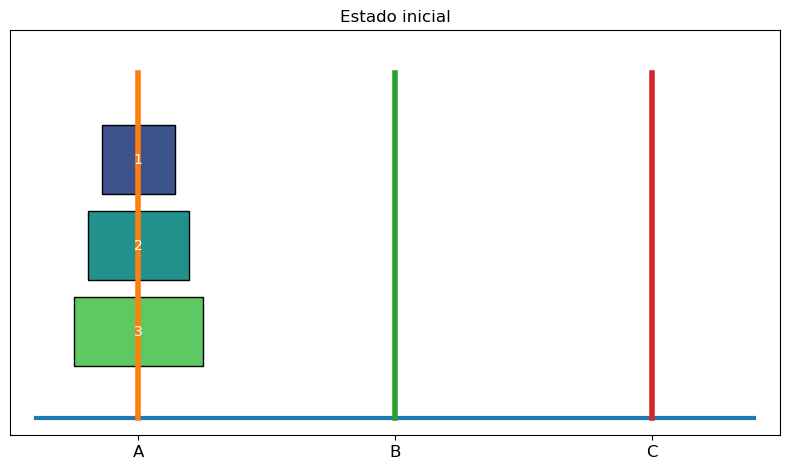

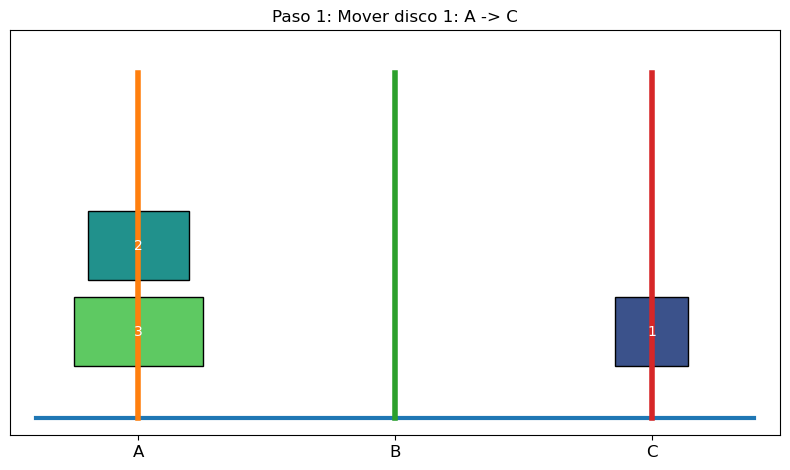

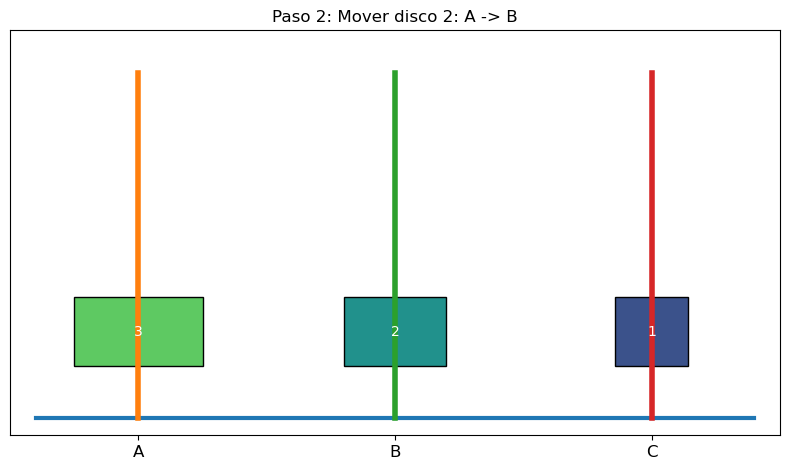

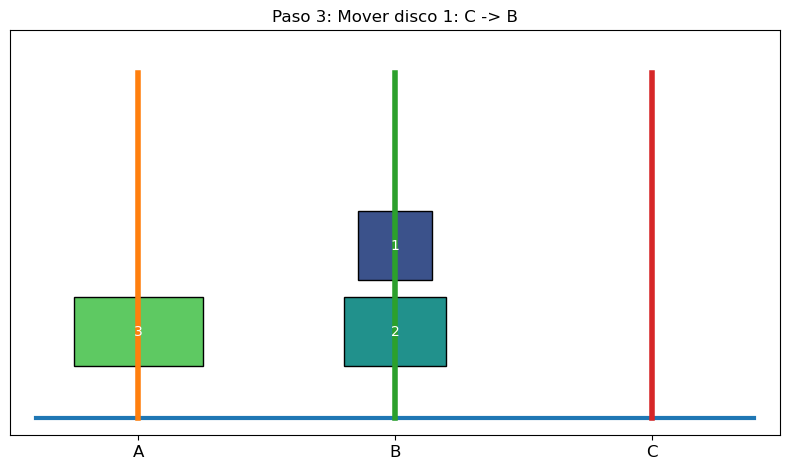

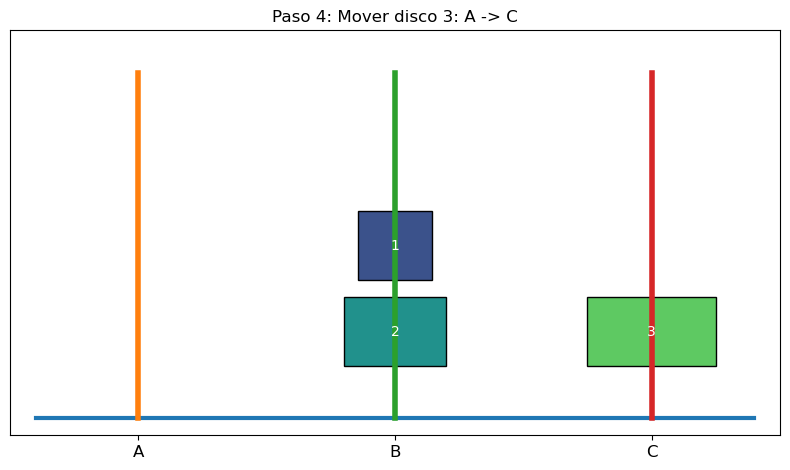

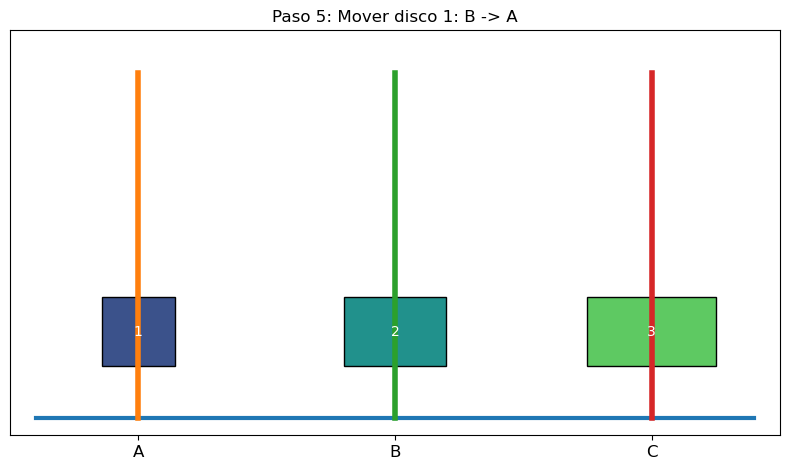

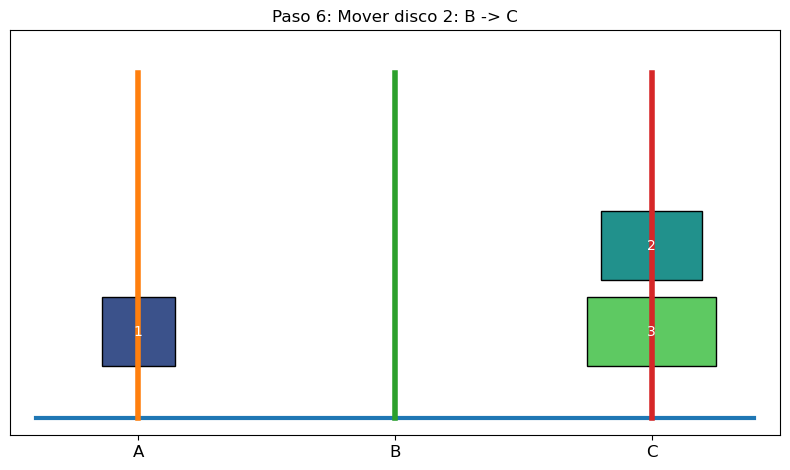

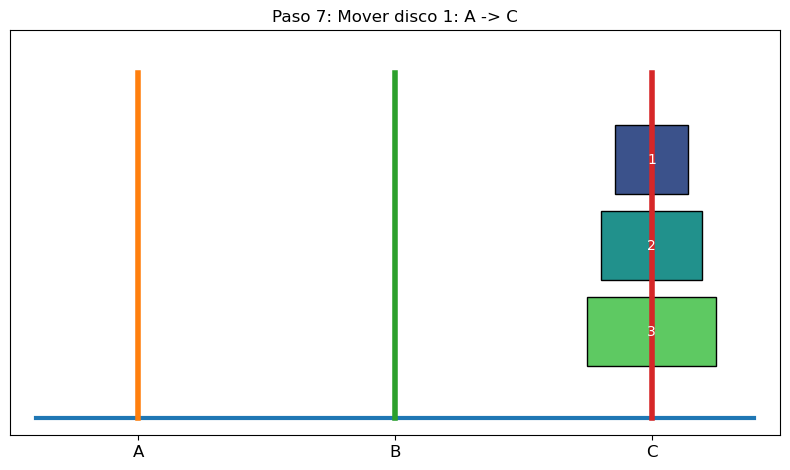

In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


# =========================
# 1) REPRESENTACION (STACKS)
# =========================
# Cada torre se modela como una pila (stack):
# - El ultimo elemento de la lista es el tope de la pila.
# - Discos con numero mas pequeno representan discos fisicamente pequenos.
#   Ejemplo con 3 discos: [3, 2, 1] (1 arriba).

def crear_estado_inicial(n_discos=3):
    """Crea el estado inicial del sistema con todos los discos en la torre A."""
    return {
        "A": list(range(n_discos, 0, -1)),
        "B": [],
        "C": [],
    }


def movimiento_valido(estado, origen, destino):
    """
    Regla de transicion del sistema:
    - Debe existir disco en la torre origen.
    - Si destino no esta vacia, el disco a mover debe ser menor que el tope destino.
    """
    if not estado[origen]:
        return False
    if not estado[destino]:
        return True
    return estado[origen][-1] < estado[destino][-1]


def mover_disco(estado, origen, destino):
    """Aplica una accion valida y actualiza el estado (transicion de estado)."""
    if not movimiento_valido(estado, origen, destino):
        raise ValueError(f"Movimiento invalido: {origen} -> {destino}")
    disco = estado[origen].pop()
    estado[destino].append(disco)
    return disco


# =====================================
# 2) ALGORITMO DE RESOLUCION (RECURSIVO)
# =====================================
# La recursion produce la secuencia minima de movimientos: 2^n - 1.

def hanoi_recursivo(n, origen, auxiliar, destino, estado, historial):
    """
    Resuelve la Torre de Hanoi recursivamente y guarda cada estado.

    historial almacena snapshots con:
    - movimiento aplicado
    - copia profunda del estado resultante
    """
    if n == 1:
        disco = mover_disco(estado, origen, destino)
        historial.append({
            "movimiento": f"Mover disco {disco}: {origen} -> {destino}",
            "estado": {k: v.copy() for k, v in estado.items()},
        })
        return

    hanoi_recursivo(n - 1, origen, destino, auxiliar, estado, historial)
    disco = mover_disco(estado, origen, destino)
    historial.append({
        "movimiento": f"Mover disco {disco}: {origen} -> {destino}",
        "estado": {k: v.copy() for k, v in estado.items()},
    })
    hanoi_recursivo(n - 1, auxiliar, origen, destino, estado, historial)


# ================================
# 3) VISUALIZACION CON MATPLOTLIB
# ================================

def dibujar_estado_torres(estado, n_discos, titulo=""):
    """Dibuja un estado de Hanoi como torres y discos apilados."""
    fig, ax = plt.subplots(figsize=(8, 4.8))

    torres = ["A", "B", "C"]
    x_positions = [1, 3, 5]
    base_y = 0
    altura_max = n_discos + 1

    # Base
    ax.plot([0.2, 5.8], [base_y, base_y], linewidth=3)

    # Postes
    for x in x_positions:
        ax.plot([x, x], [base_y, altura_max], linewidth=4)

    # Colores por disco (indice 1..n)
    cmap = plt.cm.viridis

    for torre, x in zip(torres, x_positions):
        stack = estado[torre]
        # stack[0] es el fondo, stack[-1] es la cima
        for nivel, disco in enumerate(stack, start=1):
            ancho = 0.35 + 0.22 * disco
            rect = Rectangle(
                (x - ancho / 2, nivel - 0.4),
                ancho,
                0.8,
                facecolor=cmap(disco / (n_discos + 1)),
                edgecolor="black",
            )
            ax.add_patch(rect)
            ax.text(x, nivel, str(disco), ha="center", va="center", fontsize=10, color="white")

    ax.set_xlim(0, 6)
    ax.set_ylim(-0.2, altura_max + 0.5)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(torres, fontsize=12)
    ax.set_yticks([])
    ax.set_title(titulo, fontsize=12)
    plt.tight_layout()
    plt.show()


def animar_historial(historial, n_discos, max_frames=20):
    """
    Muestra los estados uno a uno.
    - Para no saturar salida, max_frames limita la cantidad de graficos mostrados.
    """
    total = len(historial)
    print(f"Movimientos totales: {total} (esperado = {2**n_discos - 1})")

    # Mostrar estado inicial
    estado_inicial = {"A": list(range(n_discos, 0, -1)), "B": [], "C": []}
    dibujar_estado_torres(estado_inicial, n_discos, "Estado inicial")

    # Mostrar secuencia de movimientos
    limite = min(total, max_frames)
    for i in range(limite):
        paso = historial[i]
        dibujar_estado_torres(
            paso["estado"],
            n_discos,
            f"Paso {i+1}: {paso['movimiento']}"
        )

    if total > max_frames:
        print(f"Se mostraron {max_frames} de {total} estados para evitar saturar la salida.")


# =====================
# 4) EJECUCION DEL CASO
# =====================
# Número de discos a resolver (puede cambiarse para probar con diferentes tamaños)
n_discos = 3

estado = crear_estado_inicial(n_discos)
historial = []

hanoi_recursivo(n_discos, "A", "B", "C", estado, historial)

print("Primeros movimientos:")
for i, paso in enumerate(historial[:10], start=1):
    print(f"{i:2d}. {paso['movimiento']}")

print("\nEstado final:", estado)
animar_historial(historial, n_discos, max_frames=15)
